# Biological coordinates, BTox and mean44

Addresses R1.4–5 and R3.5–8/11. Computational descriptors are not measured biological mechanisms.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Three calibration features; one display sum

The localizer uses hERG, Respiratory and Neurotoxicity-DI separately. BTox is their sum for the two-dimensional display. It is not a validated ordinal toxicity scale or an assertion of equal biological effects.

In [2]:
display(table('tables/selected_markers.csv'))
vif=additional('phenotype_vif');display(vif.groupby(['diagnostic_includes_unused_hERG10','feature']).vif.agg(['min','max']))
cor=additional('phenotype_correlations');display(cor.groupby(['diagnostic_includes_unused_hERG10','a','b']).spearman.mean())

,run,selected_markers
0,butina03_seed42,hERG;Respiratory;Neurotoxicity-DI
1,butina04_seed42,hERG;Respiratory;Neurotoxicity-DI
2,butina04_seed43,hERG;Respiratory;Neurotoxicity-DI
3,butina04_seed44,hERG;Respiratory;Neurotoxicity-DI
4,butina04_seed45,hERG;Respiratory;Neurotoxicity-DI
5,butina04_seed46,hERG;Respiratory;Neurotoxicity-DI
6,butina05_seed42,hERG;Respiratory;Neurotoxicity-DI
7,random_size_matched_seed42,hERG;Respiratory;Neurotoxicity-DI
8,random_size_matched_seed43,hERG;Respiratory;Neurotoxicity-DI
9,random_size_matched_seed44,hERG;Respiratory;Neurotoxicity-DI


min      max
diagnostic_includes_unused_hERG10 feature                           
False                             Neurotoxicity-DI  1.33140  1.37336
                                  Respiratory       1.14875  1.18239
                                  hERG              1.31303  1.34488
True                              Neurotoxicity-DI  1.33258  1.37417
                                  Respiratory       1.21284  1.24761
                                  hERG              2.51559  2.67190
                                  hERG-10um         2.47769  2.61402

diagnostic_includes_unused_hERG10  a                 b               
False                              Respiratory       Neurotoxicity-DI    0.34829
                                   hERG              Neurotoxicity-DI    0.47960
                                                     Respiratory         0.25188
True                               Neurotoxicity-DI  hERG-10um           0.41271
                                   Respiratory       Neurotoxicity-DI    0.34829
                                                     hERG-10um           0.34422
                                   hERG              Neurotoxicity-DI    0.47960
                                                     Respiratory         0.25188
                                                     hERG-10um           0.80202
Name: spearman, dtype: float64

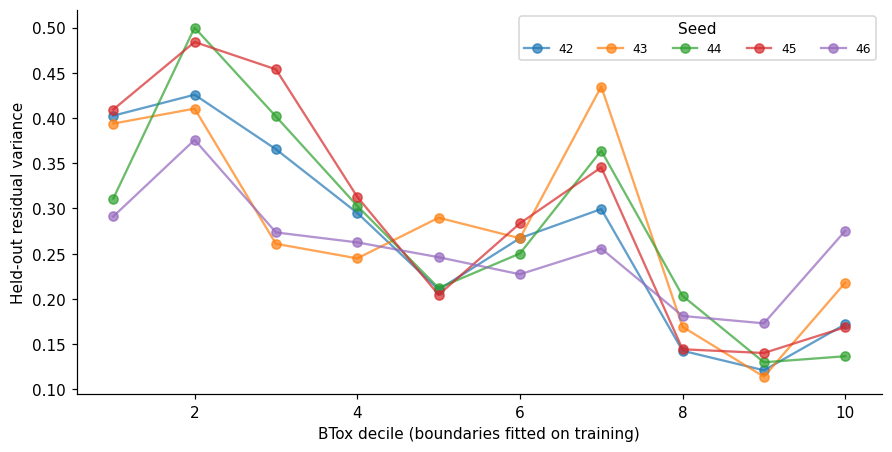

In [3]:
dec=additional('btox_residual_deciles');fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
for seed,g in dec.groupby('seed'):ax.plot(g.bin,g.residual_variance,'o-',alpha=.7,label=str(seed))
ax.set(xlabel='BTox decile (boundaries fitted on training)',ylabel='Held-out residual variance');ax.legend(title='Seed',ncol=5,fontsize=8);finish(fig,'btox_residual_variance')

## Target-wise docking normalization

For every target, subtract the proper-training mean and divide by its proper-training SD, then average all 44 standardized scores. Standardize the resulting four-dimensional coordinate vector on proper training. Keep point predictors, residuals and partitions fixed. Do not choose weights using test results.

In [4]:
d=dataset();seed=42;folder=RESULTS/f'runs/butina04_seed{seed}'
manifest=pd.read_csv(folder/'split_manifest.csv');train_ids=manifest.loc[manifest.role.eq('train'),'ligand_id']
cfg=read_json(folder/'complete.json');p=pd.read_csv(folder/'test_predictions.csv');cal=pd.read_csv(folder/'calibration_predictions.csv')
energy=d[PROTEINS];mu=energy.loc[train_ids].mean();sd=energy.loc[train_ids].std(ddof=0)
assert (sd>0).all()
mean_normalized=((energy-mu)/sd).mean(axis=1)
raw=pd.DataFrame(np.column_stack([mean_normalized,d[cfg['selected_markers']].clip(0,1)]),index=d.index)
z=(raw-raw.loc[train_ids].mean())/raw.loc[train_ids].std(ddof=0)
w,ne=local_intervals(z.loc[p.ligand_id].to_numpy(),z.loc[cal.ligand_id].to_numpy(),cal.abs_residual.to_numpy(),cfg['global_quantile'])
score=float((w+20*np.maximum(p.abs_residual-w/2,0)).mean())
checks=additional('docking_normalization')
assert np.isclose(score,checks[checks.seed.eq(seed)].normalized_score.iloc[0])
print('Recomputed normalized interval score:',score)

Recomputed normalized interval score: 2.341152225605094


,normalized_score,reference_score,delta,normalized_coverage
comparison,,,,
phenotype_only,2.40914,2.42035,-0.01121,0.89355
raw_mean44,2.40914,2.39742,0.01172,0.89355


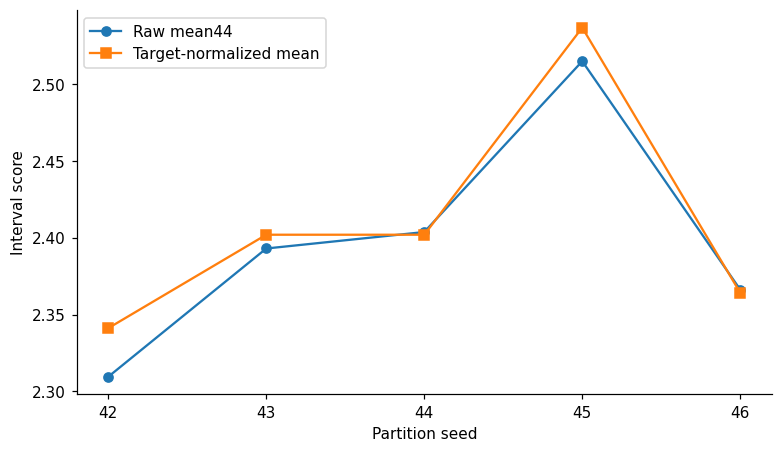

In [5]:
display(checks.groupby('comparison')[['normalized_score','reference_score','delta','normalized_coverage']].mean())
fig,ax=plt.subplots(figsize=(7,4),layout='constrained')
g=checks[checks.comparison.eq('raw_mean44')]
ax.plot(g.seed,g.reference_score,'o-',label='Raw mean44');ax.plot(g.seed,g.normalized_score,'s-',label='Target-normalized mean')
ax.set(xticks=range(42,47),xlabel='Partition seed',ylabel='Interval score');ax.legend();finish(fig,'docking_normalization')

## What does mean44 add beyond the three phenotype descriptors?

Compare joint localization with phenotype-only localization on the same residuals. The extra gain is small; several paired uncertainty intervals include zero. Retain mean44 as a fixed-panel computational summary without calling it binding affinity or a combined MIE burden.

In [6]:
display(table('docking_incremental_localization.csv'))

,seed,joint_minus_pheno_score,ci_low,ci_high
0,42,-0.01622,-0.04299,0.01149
1,43,-0.02474,-0.06130,0.00341
2,44,-0.02397,-0.04223,-0.00516
3,45,-0.01890,-0.06347,0.01853
4,46,-0.03082,-0.05883,-0.00625
